1. Imports & Setup

In [ ]:
import torch
from torch import nn
import math
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

2. Data Generation

In [ ]:
def generate_sine_data(n=1024):
    # Sine curve: x1 in [0, 2pi], x2 = sin(x1)
    train_data = torch.zeros((n, 2))
    train_data[:, 0] = 2.0 * math.pi * torch.rand(n)
    train_data[:, 1] = torch.sin(train_data[:, 0])
    train_labels = torch.zeros(n)
    train_set = [(train_data[i], train_labels[i]) for i in range(n)]
    return train_data, train_set


def generate_mixture_of_gaussians(n=1024, n_components=3, seed=42):
    # 3 Gaussian clusters arranged on a unit circle
    # Tests mode collapse: generator may only learn subset of modes
    rng = np.random.RandomState(seed)
    centres = [
        (np.cos(2 * np.pi * k / n_components),
         np.sin(2 * np.pi * k / n_components))
        for k in range(n_components)
    ]
    std = 0.15
    samples_per_component = n // n_components
    all_samples = []
    for (cx, cy) in centres:
        xs = rng.normal(cx, std, samples_per_component)
        ys = rng.normal(cy, std, samples_per_component)
        all_samples.append(np.column_stack([xs, ys]))
    data_np = np.vstack(all_samples).astype(np.float32)
    np.random.shuffle(data_np)
    train_data = torch.from_numpy(data_np)
    train_labels = torch.zeros(len(train_data))
    train_set = [(train_data[i], train_labels[i]) for i in range(len(train_data))]
    return train_data, train_set


def make_dataloader(train_set, batch_size=32):
    # drop_last=True drops the final incomplete batch to keep batch sizes consistent
    return torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, drop_last=True)

3. Visualisation Functions

In [ ]:
def plot_training_data(train_data, title="Training Data", xlabel="x1", ylabel="x2"):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_data[:, 0].numpy(), train_data[:, 1].numpy(),
            '.', markersize=3, alpha=0.6, color='steelblue', label='Training data')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_losses(g_losses, d_losses, title="GAN Training Losses"):
    # Both losses should converge near ln2 = 0.693 (discriminator at 50% accuracy)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(g_losses, label='Generator loss', color='tomato', linewidth=1.2)
    ax.plot(d_losses, label='Discriminator loss', color='steelblue', linewidth=1.2)
    ax.axhline(y=math.log(2), color='grey', linestyle='--', linewidth=0.8,
               label='Ideal convergence (ln2 = 0.693)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()


def generate_and_plot(generator, train_data, n_samples=1000, title="Generated vs Real"):
    # eval() disables dropout during inference
    generator.eval()
    with torch.no_grad():
        generated = generator(torch.randn(n_samples, 2)).numpy()
    generator.train()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_data[:, 0].numpy(), train_data[:, 1].numpy(),
            '.', markersize=4, alpha=0.5, color='steelblue', label='Real data')
    ax.plot(generated[:, 0], generated[:, 1],
            '.', markersize=6, alpha=0.6, color='tomato', label='Generated data')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    plt.tight_layout()
    plt.show()


def compare_architectures_plot(gen_orig, gen_mod, train_data,
                                label_orig="Original", label_mod="Modified"):
    # Same axis limits for fair visual comparison
    def get_generated(gen):
        gen.eval()
        with torch.no_grad():
            out = gen(torch.randn(1000, 2)).numpy()
        gen.train()
        return out

    g_orig = get_generated(gen_orig)
    g_mod  = get_generated(gen_mod)
    real   = train_data.numpy()

    all_x = np.concatenate([real[:, 0], g_orig[:, 0], g_mod[:, 0]])
    all_y = np.concatenate([real[:, 1], g_orig[:, 1], g_mod[:, 1]])
    xlim = (all_x.min() - 0.2, all_x.max() + 0.2)
    ylim = (all_y.min() - 0.2, all_y.max() + 0.2)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, g_np, label in zip(axes, [g_orig, g_mod], [label_orig, label_mod]):
        ax.plot(real[:, 0], real[:, 1], '.', markersize=4,
                alpha=0.5, color='steelblue', label='Real data')
        ax.plot(g_np[:, 0], g_np[:, 1], '.', markersize=6,
                alpha=0.6, color='tomato', label='Generated data')
        ax.set_title(f"Architecture: {label}", fontweight='bold')
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.legend()
    plt.suptitle("Architecture Comparison: Generated vs Real", fontweight='bold')
    plt.tight_layout()
    plt.show()


def compare_loss_curves(g_losses_orig, d_losses_orig, g_losses_mod, d_losses_mod,
                        label_orig="Original", label_mod="Modified"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(g_losses_orig, label=f'G loss - {label_orig}', color='tomato', linewidth=1.2)
    ax.plot(d_losses_orig, label=f'D loss - {label_orig}', color='steelblue', linewidth=1.2)
    ax.plot(g_losses_mod,  label=f'G loss - {label_mod}', color='tomato', linewidth=1.2, linestyle='--')
    ax.plot(d_losses_mod,  label=f'D loss - {label_mod}', color='steelblue', linewidth=1.2, linestyle='--')
    ax.axhline(y=math.log(2), color='grey', linestyle=':', linewidth=0.8, label='Ideal (ln2)')
    ax.set_title("Loss Curve Comparison: Original vs Modified", fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

4. Model Definitions

In [ ]:
# Discriminator: 2->256->128->64->1
# ReLU + Dropout(0.3) prevents overfitting; Sigmoid outputs probability [0,1]
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


# Generator: 2->16->32->2
# No dropout: generator needs full capacity to learn the data mapping
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        return self.model(x)


# Modified Discriminator: LeakyReLU(0.2) prevents dying ReLU neurons
# Keeps gradient signal alive for negative activations (Radford et al., 2016)
class DiscriminatorV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


# Modified Generator: 2->32->64->128->2
# Deeper and wider for better capacity on complex distributions
class GeneratorV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.model(x)

5. Training Function

In [ ]:
def get_optimizers(generator, discriminator, lr=0.001):
    # Adam: adaptive learning rate, standard choice for GAN training
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr)
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr)
    return optimizer_G, optimizer_D


def train_gan(generator, discriminator, train_loader,
              optimizer_G, optimizer_D, loss_fn,
              num_epochs=2000, print_every=200):

    batch_size = train_loader.batch_size
    g_losses = []
    d_losses = []

    for epoch in range(num_epochs):
        g_loss_epoch = 0.0
        d_loss_epoch = 0.0
        n_batches = 0

        for n, (real_samples, _) in enumerate(train_loader):
            # --- Discriminator training ---
            # Real samples labelled 1, generated samples labelled 0
            real_labels = torch.ones((batch_size, 1))
            fake_labels = torch.zeros((batch_size, 1))
            latent = torch.randn((batch_size, 2))
            generated = generator(latent)
            all_samples = torch.cat((real_samples, generated))
            all_labels  = torch.cat((real_labels, fake_labels))

            discriminator.zero_grad()
            out_d = discriminator(all_samples)
            loss_d = loss_fn(out_d, all_labels)
            loss_d.backward()
            optimizer_D.step()

            # --- Generator training ---
            # Generator wants discriminator to classify its output as real (label=1)
            latent = torch.randn((batch_size, 2))
            generator.zero_grad()
            generated = generator(latent)
            out_g = discriminator(generated)
            loss_g = loss_fn(out_g, real_labels)
            loss_g.backward()
            optimizer_G.step()

            g_loss_epoch += loss_g.item()
            d_loss_epoch += loss_d.item()
            n_batches += 1

        g_losses.append(g_loss_epoch / n_batches)
        d_losses.append(d_loss_epoch / n_batches)

        # print_every < num_epochs guard prevents epoch 0 printing in silent runs
        if print_every < num_epochs and epoch % print_every == 0:
            print(f"Epoch {epoch:4d} | Loss G: {g_losses[-1]:.4f} | Loss D: {d_losses[-1]:.4f}")

    return g_losses, d_losses

6. Task 1.1 - Sine-Wave GAN: Data

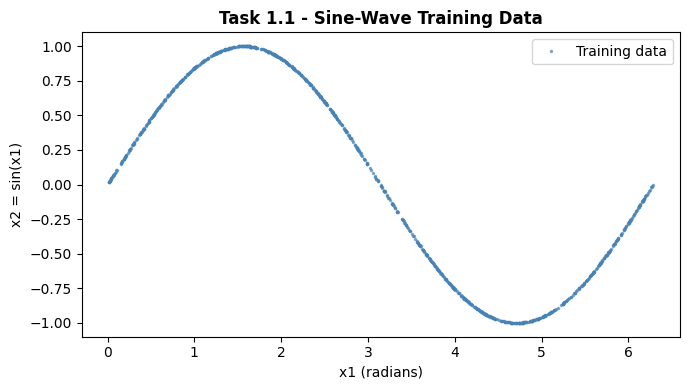

In [ ]:
torch.manual_seed(42)

sine_train_data, sine_train_set = generate_sine_data(n=1024)

plot_training_data(sine_train_data,
                   title="Task 1.1 - Sine-Wave Training Data",
                   xlabel="x1 (radians)", ylabel="x2 = sin(x1)")

7. Task 1.1 - Sine-Wave GAN: Train

In [ ]:
torch.manual_seed(42)

sine_discriminator = Discriminator()
sine_generator     = Generator()
loss_function      = nn.BCELoss()

sine_optimizer_G, sine_optimizer_D = get_optimizers(
    sine_generator, sine_discriminator, lr=0.001)
sine_loader = make_dataloader(sine_train_set, batch_size=32)

sine_g_losses, sine_d_losses = train_gan(
    sine_generator, sine_discriminator, sine_loader,
    sine_optimizer_G, sine_optimizer_D,
    loss_function, num_epochs=2000, print_every=200)

Epoch    0 | Loss G: 1.0893 | Loss D: 0.4363
Epoch  200 | Loss G: 0.7997 | Loss D: 0.6576
Epoch  400 | Loss G: 0.7129 | Loss D: 0.6868
Epoch  600 | Loss G: 0.8010 | Loss D: 0.6658
Epoch  800 | Loss G: 0.7180 | Loss D: 0.6808
Epoch 1000 | Loss G: 0.7473 | Loss D: 0.6988
Epoch 1200 | Loss G: 0.7054 | Loss D: 0.6857
Epoch 1400 | Loss G: 0.7128 | Loss D: 0.6839
Epoch 1600 | Loss G: 0.7128 | Loss D: 0.6811
Epoch 1800 | Loss G: 0.7299 | Loss D: 0.6818


8. Task 1.1 - Sine-Wave GAN: Results

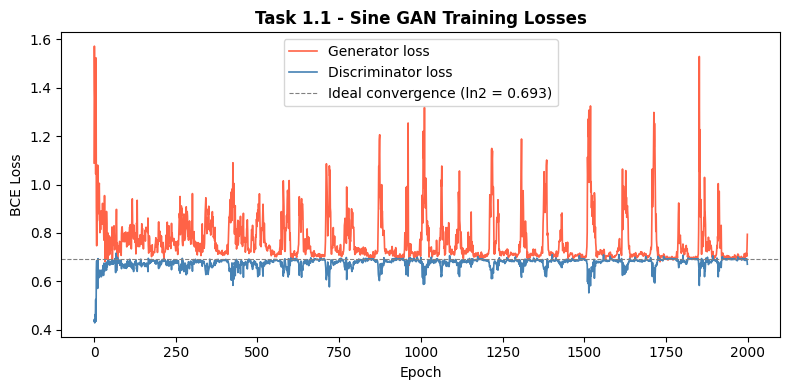

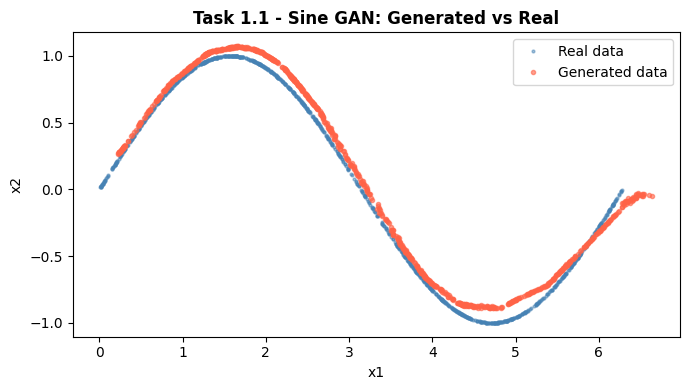

In [ ]:
plot_losses(sine_g_losses, sine_d_losses,
            title="Task 1.1 - Sine GAN Training Losses")

generate_and_plot(sine_generator, sine_train_data, n_samples=1000,
                  title="Task 1.1 - Sine GAN: Generated vs Real")

9. Task 1.1 - Seed Sensitivity Analysis

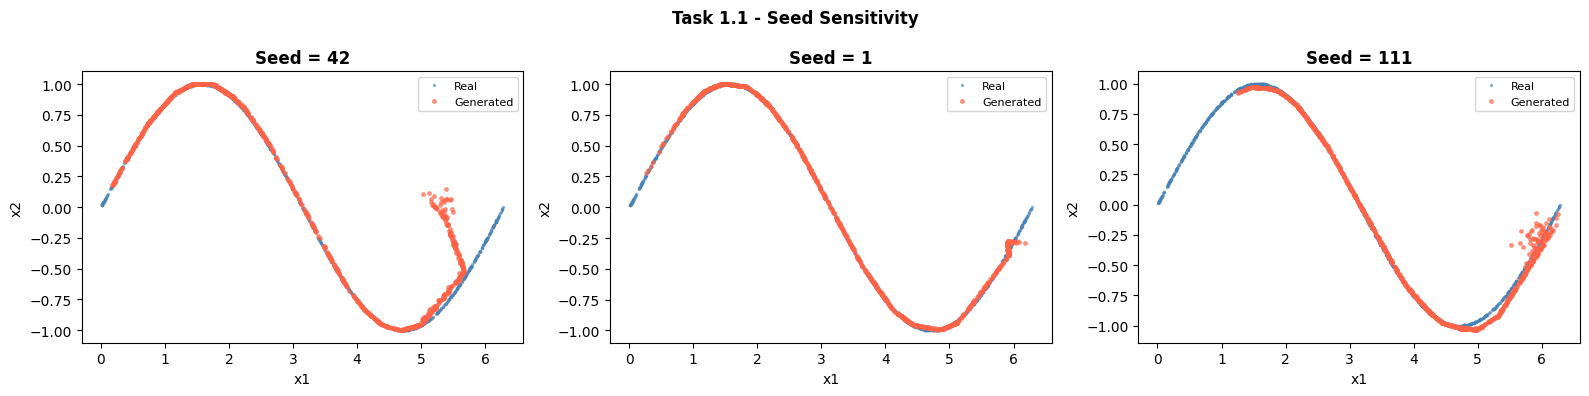

In [ ]:
# Trains 3 separate GANs with different seeds to show training instability
# seed=42: good fit; seed=1: minor divergence; seed=111: misses curve edges
seeds = [42, 1, 111]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, seed in zip(axes, seeds):
    torch.manual_seed(seed)
    gen_seed  = Generator()
    disc_seed = Discriminator()
    opt_g, opt_d = get_optimizers(gen_seed, disc_seed, lr=0.001)
    train_gan(gen_seed, disc_seed,
              make_dataloader(sine_train_set, batch_size=32),
              opt_g, opt_d, nn.BCELoss(),
              num_epochs=2000, print_every=99999)

    gen_seed.eval()
    with torch.no_grad():
        gen_np = gen_seed(torch.randn(1000, 2)).numpy()
    gen_seed.train()

    real_np = sine_train_data.numpy()
    ax.plot(real_np[:, 0], real_np[:, 1], '.', markersize=3,
            alpha=0.5, color='steelblue', label='Real')
    ax.plot(gen_np[:, 0], gen_np[:, 1], '.', markersize=5,
            alpha=0.6, color='tomato', label='Generated')
    ax.set_title(f"Seed = {seed}", fontweight='bold')
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(fontsize=8)

plt.suptitle("Task 1.1 - Seed Sensitivity", fontweight='bold')
plt.tight_layout()
plt.show()

10. Task 1.2 - Mixture of Gaussians: Data

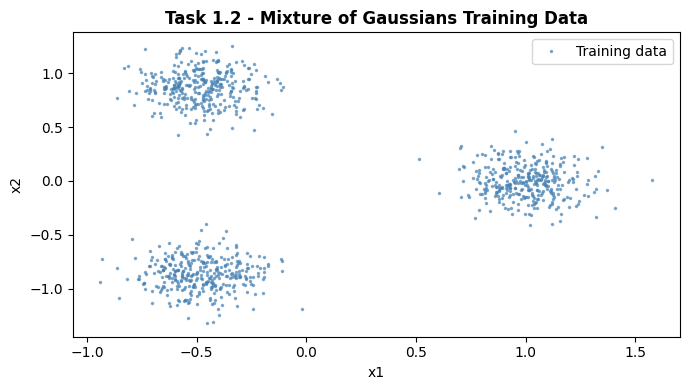

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

mog_train_data, mog_train_set = generate_mixture_of_gaussians(
    n=1024, n_components=3, seed=42)

plot_training_data(mog_train_data,
                   title="Task 1.2 - Mixture of Gaussians Training Data",
                   xlabel="x1", ylabel="x2")

11. Task 1.2 - Mixture of Gaussians: Train

In [ ]:
torch.manual_seed(42)

mog_discriminator = Discriminator()
mog_generator     = Generator()
mog_optimizer_G, mog_optimizer_D = get_optimizers(
    mog_generator, mog_discriminator, lr=0.001)
mog_loader = make_dataloader(mog_train_set, batch_size=32)

mog_g_losses, mog_d_losses = train_gan(
    mog_generator, mog_discriminator, mog_loader,
    mog_optimizer_G, mog_optimizer_D,
    nn.BCELoss(), num_epochs=2000, print_every=200)

Epoch    0 | Loss G: 0.9571 | Loss D: 0.5326
Epoch  200 | Loss G: 0.9622 | Loss D: 0.5526
Epoch  400 | Loss G: 0.9385 | Loss D: 0.5593
Epoch  600 | Loss G: 0.9770 | Loss D: 0.5552
Epoch  800 | Loss G: 0.8996 | Loss D: 0.5612
Epoch 1000 | Loss G: 0.9501 | Loss D: 0.5592
Epoch 1200 | Loss G: 0.8769 | Loss D: 0.5645
Epoch 1400 | Loss G: 0.9624 | Loss D: 0.5538
Epoch 1600 | Loss G: 0.9851 | Loss D: 0.5420
Epoch 1800 | Loss G: 0.9986 | Loss D: 0.5473


12. Task 1.2 - Mixture of Gaussians: Results

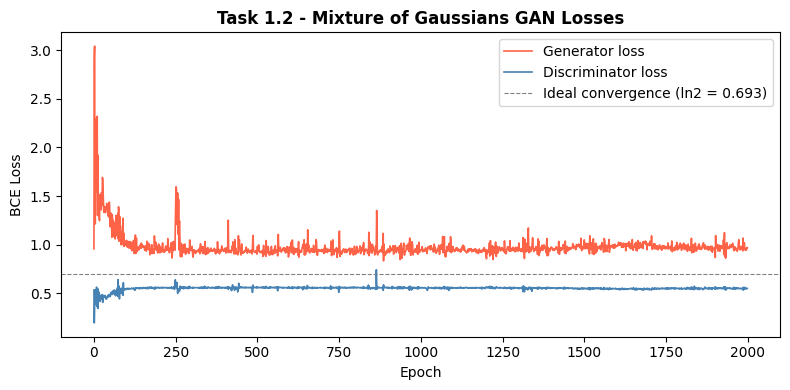

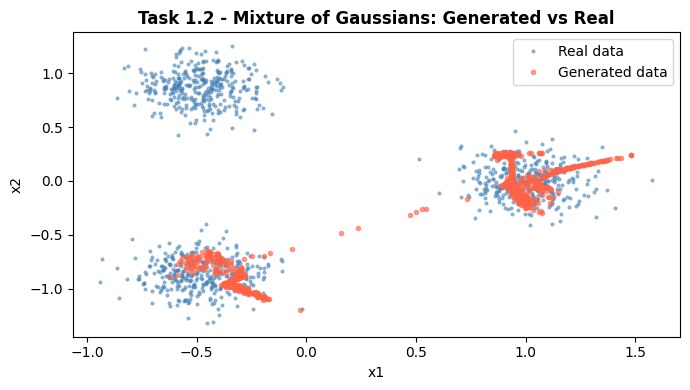

In [ ]:
plot_losses(mog_g_losses, mog_d_losses,
            title="Task 1.2 - Mixture of Gaussians GAN Losses")

generate_and_plot(mog_generator, mog_train_data, n_samples=1000,
                  title="Task 1.2 - Mixture of Gaussians: Generated vs Real")

13. Task 1.3 - Modified Architecture: Train

In [ ]:
# Same seed, dataloader, lr, epochs as Task 1.2 for fair comparison
torch.manual_seed(42)

mod_discriminator = DiscriminatorV2()
mod_generator     = GeneratorV2()
mod_optimizer_G, mod_optimizer_D = get_optimizers(
    mod_generator, mod_discriminator, lr=0.001)

mod_g_losses, mod_d_losses = train_gan(
    mod_generator, mod_discriminator, mog_loader,
    mod_optimizer_G, mod_optimizer_D,
    nn.BCELoss(), num_epochs=2000, print_every=200)

Epoch    0 | Loss G: 1.0545 | Loss D: 0.5628
Epoch  200 | Loss G: 1.3346 | Loss D: 0.3798
Epoch  400 | Loss G: 0.8839 | Loss D: 0.5665
Epoch  600 | Loss G: 0.8021 | Loss D: 0.6675
Epoch  800 | Loss G: 0.6581 | Loss D: 0.6923
Epoch 1000 | Loss G: 0.9510 | Loss D: 0.5325
Epoch 1200 | Loss G: 0.7183 | Loss D: 0.6964
Epoch 1400 | Loss G: 0.7444 | Loss D: 0.6825
Epoch 1600 | Loss G: 0.9389 | Loss D: 0.5840
Epoch 1800 | Loss G: 0.7154 | Loss D: 0.6926


14. Task 1.3 - Modified Architecture: Comparison

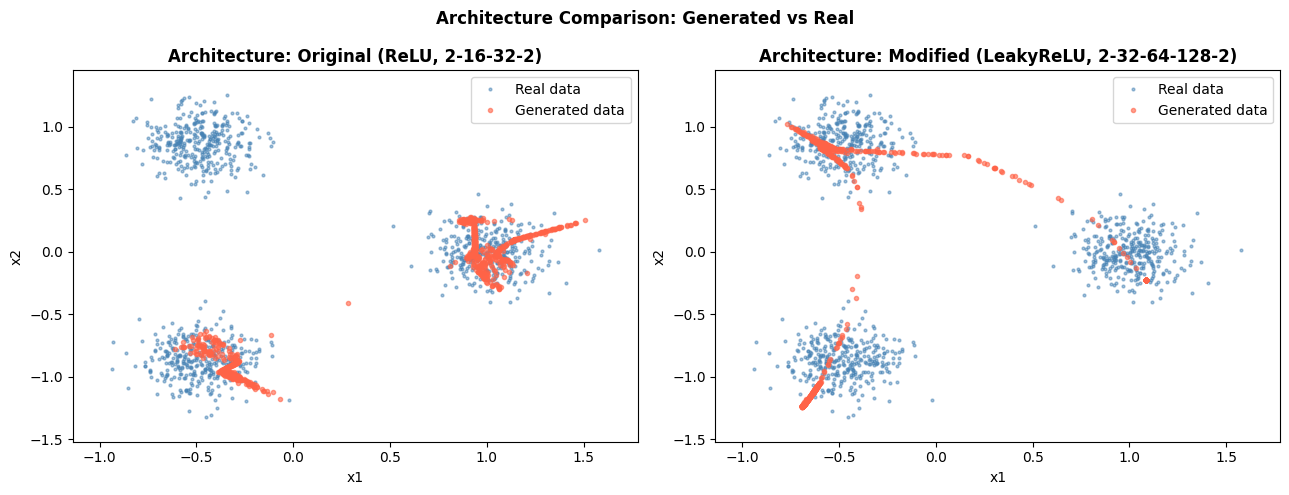

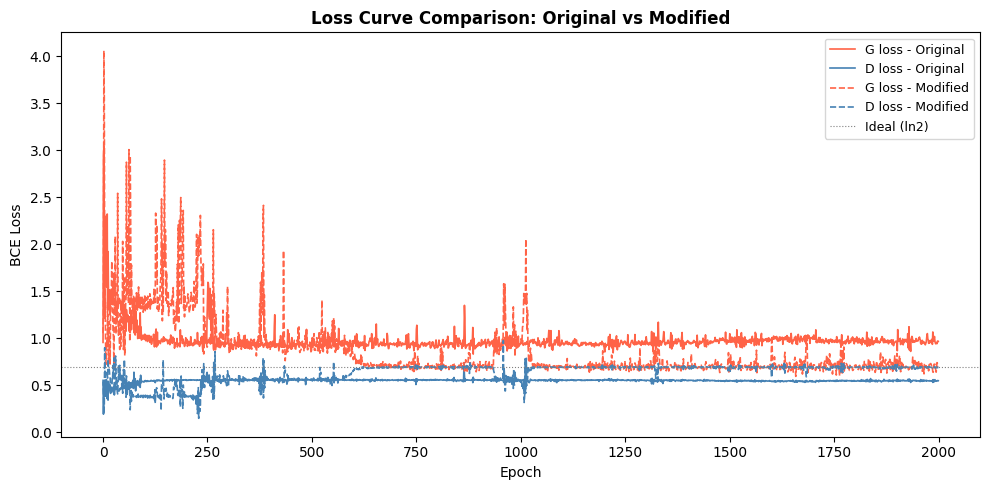

In [ ]:
compare_architectures_plot(
    mog_generator, mod_generator, mog_train_data,
    label_orig="Original (ReLU, 2-16-32-2)",
    label_mod="Modified (LeakyReLU, 2-32-64-128-2)")

compare_loss_curves(
    mog_g_losses, mog_d_losses,
    mod_g_losses, mod_d_losses,
    label_orig="Original", label_mod="Modified")